In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
pip install torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.4 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.10.19
    Uninstalling nvidia-curand-cu12-

In [2]:
pip install torchmetrics

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import json
import torch
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights
from tqdm import tqdm

In [4]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [5]:
# ----- Configuration -----
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
dataset_path = '/kaggle/input/tacotrashdataset'
# Le dossier contenant les images et le fichier annotations.json
data_path = os.path.join(dataset_path, "data")
print("Contenu du dossier data:", os.listdir(data_path))

Contenu du dossier data: ['batch_4', 'batch_1', 'batch_5', 'batch_14', 'batch_6', 'annotations.json', 'batch_13', 'batch_15', 'batch_3', 'batch_10', 'batch_12', 'batch_11', 'batch_8', 'batch_2', 'batch_7', 'batch_9']


In [7]:
ANNOTATION_PATH = os.path.join(data_path, "annotations.json")
BATCH_SIZE = 4
NUM_EPOCHS = 30
IMG_SIZE = 800

In [8]:
# ----- Chargement des annotations TACO -----
with open(ANNOTATION_PATH) as f:
    annotations = json.load(f)
# Mapping des catégories
category_id_map = {cat['id']: idx+1 for idx, cat in enumerate(annotations['categories'])}
idx_to_class = {idx+1: cat['name'] for idx, cat in enumerate(annotations['categories'])}

In [9]:
def resize_with_aspect_ratio(img, target_size):
    original_width, original_height = img.size
    if original_width > original_height:
        new_width = target_size
        new_height = int(target_size * original_height / original_width)
    else:
        new_height = target_size
        new_width = int(target_size * original_width / original_height)
    return img.resize((new_width, new_height), Image.BILINEAR)

In [24]:
# ----- Classe Dataset Personnalisée -----
class TacoDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms=None):
        """
        Ici, 'root' est le dossier 'data' qui contient annotations.json
        ainsi que les dossiers batch_x avec les images.
        """
        self.root = root
        self.transforms = transforms

        # Charge le fichier d'annotations
        with open(os.path.join(root, "annotations.json")) as f:
            data = json.load(f)

        self.valid_images = []
        self.annotations = []
        missing_files = []

        valid_ids = set()
        for img in data['images']:
            # 'file_name' doit contenir le chemin relatif (ex: "batch_1/xxx.jpg")
            img_path = os.path.join(self.root, img['file_name'])
            if os.path.exists(img_path):
                self.valid_images.append(img)
                valid_ids.add(img['id'])
            else:
                missing_files.append(img_path)

        # Conserver uniquement les annotations des images valides
        self.annotations = [ann for ann in data['annotations'] if ann['image_id'] in valid_ids]
        self.cat_map = category_id_map

        print(f"Loaded {len(self.valid_images)} images with {len(self.annotations)} annotations")
        print(f"Skipped {len(missing_files)} missing files")

    def __len__(self):
        return len(self.valid_images)

    def __getitem__(self, idx):
        img_info = self.valid_images[idx]
        img_path = os.path.join(self.root, img_info['file_name'])
    
        img = Image.open(img_path).convert("RGB")
        original_width, original_height = img.size
        anns = [a for a in self.annotations if a['image_id'] == img_info['id']]
    
        boxes, labels, masks = [], [], []
        for ann in anns:
            x, y, w, h = ann['bbox']
            x0, y0, x1, y1 = x, y, x + w, y + h
            if x1 <= x0 or y1 <= y0:
                continue
            boxes.append([x0, y0, x1, y1])
            labels.append(self.cat_map.get(ann['category_id'], 0))
    
            mask = Image.new('L', (original_width, original_height), 0)
            draw = ImageDraw.Draw(mask)
            valid = False
            for seg in ann['segmentation']:
                poly = np.array(seg).reshape(-1, 2)
                poly[:, 0] = np.clip(poly[:, 0], 0, original_width - 1)
                poly[:, 1] = np.clip(poly[:, 1], 0, original_height - 1)
                if len(poly) < 3:
                    continue
                draw.polygon(poly.flatten().tolist(), outline=1, fill=1)
                valid = True
            if valid:
                masks.append(np.array(mask))
            else:
                boxes.pop()
                labels.pop()
    
        if len(boxes) == 0:
            return None, None
    
        img = resize_with_aspect_ratio(img, IMG_SIZE)
        new_width, new_height = img.size
    
        masks_resized = [Image.fromarray(m).resize((new_width, new_height), Image.NEAREST) for m in masks]
        masks_tensor = torch.stack([torch.from_numpy(np.array(m)) for m in masks_resized])

        scale_x = new_width / original_width
        scale_y = new_height / original_height
        boxes = [[b[0]*scale_x, b[1]*scale_y, b[2]*scale_x, b[3]*scale_y] for b in boxes]
    
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
    
        target = {"boxes": boxes, "labels": labels, "masks": masks_tensor}
    
        if self.transforms:
            img = self.transforms(img)
    
        return img, target


In [25]:
# ----- Fonction de Collate -----
def collate_fn(batch):
    batch = [b for b in batch if b[0] is not None]
    return tuple(zip(*batch)) if batch else ([], [])

In [26]:
# ----- Transforms -----
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [27]:
# ----- Définition du modèle -----
def get_model(num_classes):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(
        weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT
    )
    in_features_box = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features_box, num_classes)

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)
    return model

In [28]:
# ----- Chargement des données -----
# Ici, on passe data_path comme dossier racine, car il contient annotations.json et les images
dataset = TacoDataset(data_path, transforms=transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False,
                        num_workers=0, collate_fn=collate_fn)

Loaded 1500 images with 4784 annotations
Skipped 0 missing files


In [31]:
def get_num_classes_from_loader(data_loader):
    classes_set = set()
    for _, targets in data_loader:
        for t in targets:
            classes_set.update(t['labels'].cpu().numpy())
    return max(classes_set) + 1  # +1 car classes en 0-based

NUM_CLASSES = get_num_classes_from_loader(train_loader)
print("Nombre de classes détectées dans le dataset :", NUM_CLASSES)

Nombre de classes détectées dans le dataset : 61


In [32]:
model = get_model(NUM_CLASSES).to(DEVICE)

In [33]:
# ----- Optimiseur et Scheduler -----
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [34]:
from torchvision.ops import box_iou

def evaluate_model(model, data_loader, device):
    model.eval()
    iou_scores = []
    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc="Validation"):
            if not images:
                continue

            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            outputs = model(images)

            for output, target in zip(outputs, targets):
                if len(output['boxes']) == 0 or len(target['boxes']) == 0:
                    continue

                ious = box_iou(output['boxes'].cpu(), target['boxes'].cpu())
                max_ious = ious.max(dim=1)[0]
                iou_scores.extend(max_ious.tolist())

    mean_iou = np.mean(iou_scores) if iou_scores else 0.0
    return mean_iou

In [35]:
def evaluate_map(model, data_loader, device, map_metric):
    model.eval()
    map_metric.reset()

    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc="mAP Evaluation"):
            if not images:
                continue
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            outputs = model(images)

            preds = []
            for o in outputs:
                preds.append({
                    'boxes': o['boxes'].detach().cpu(),
                    'scores': o['scores'].detach().cpu(),
                    'labels': o['labels'].detach().cpu()
                })

            gts = []
            for t in targets:
                gts.append({
                    'boxes': t['boxes'].detach().cpu(),
                    'labels': t['labels'].detach().cpu()
                })

            map_metric.update(preds, gts)

    result = map_metric.compute()
    return result


In [40]:
class EarlyStopping:
    def __init__(self, patience=5, verbose=False):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_metric, model):
        score = val_metric
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(model)
        elif score < self.best_score:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(model)
            self.counter = 0
    def save_checkpoint(self, model):
        # Ici, sauvegarde le modèle si besoin
        pass

 

In [41]:
early_stopping = EarlyStopping(patience=5)
train_losses = []
val_ious = []
map_metric = MeanAveragePrecision(iou_type="bbox")

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    valid_batches = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        if not batch[0]:  # Vérifie si le batch est vide
            continue

        images = [img.to(DEVICE) for img in batch[0]]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in batch[1]]

        loss_dict = model(images, targets)
        loss = sum(l for l in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        valid_batches += 1

    # Calcul de la moyenne de perte
    avg_loss = epoch_loss / valid_batches if valid_batches else 0.0
    train_losses.append(avg_loss)

    # Évaluation
    val_iou = evaluate_model(model, val_loader, DEVICE)
    val_ious.append(val_iou)

    val_map_result = evaluate_map(model, val_loader, DEVICE, map_metric)
    val_map_50 = val_map_result['map_50'].item()
    print(f"[Epoch {epoch+1}/{NUM_EPOCHS}] Loss: {avg_loss:.4f} | Val IoU: {val_iou:.4f} | Val mAP@0.5: {val_map_50:.4f}")



    # Step scheduler (optionnel si tu veux l’utiliser)
    if isinstance(lr_scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        lr_scheduler.step(val_iou)
    else:
        lr_scheduler.step()

    # Early stopping
    early_stopping(val_iou, model)
    if early_stopping.early_stop:
        print("🔴 Early stopping déclenché. Fin de l'entraînement.")
        break


mAP Evaluation: 100%|██████████| 300/300 [01:24<00:00,  3.56it/s]


[Epoch 1/30] Loss: 0.7473 | Val IoU: 0.2960 | Val mAP@0.5: 0.0421


mAP Evaluation: 100%|██████████| 300/300 [01:18<00:00,  3.84it/s]


[Epoch 2/30] Loss: 0.6257 | Val IoU: 0.3590 | Val mAP@0.5: 0.0534


mAP Evaluation: 100%|██████████| 300/300 [01:19<00:00,  3.76it/s]


...

[Epoch 8/30] Loss: 0.4970 | Val IoU: 0.4061 | Val mAP@0.5: 0.0683


mAP Evaluation: 100%|██████████| 300/300 [01:20<00:00,  3.73it/s]


[Epoch 9/30] Loss: 0.5174 | Val IoU: 0.4045 | Val mAP@0.5: 0.0690


mAP Evaluation: 100%|██████████| 300/300 [01:20<00:00,  3.74it/s]


[Epoch 10/30] Loss: 0.5169 | Val IoU: 0.4047 | Val mAP@0.5: 0.0689
🔴 Early stopping déclenché. Fin de l'entraînement.


In [ ]:
# Sauvegarde du modèle
torch.save(model.state_dict(), "maskrcnn_taco.pth")

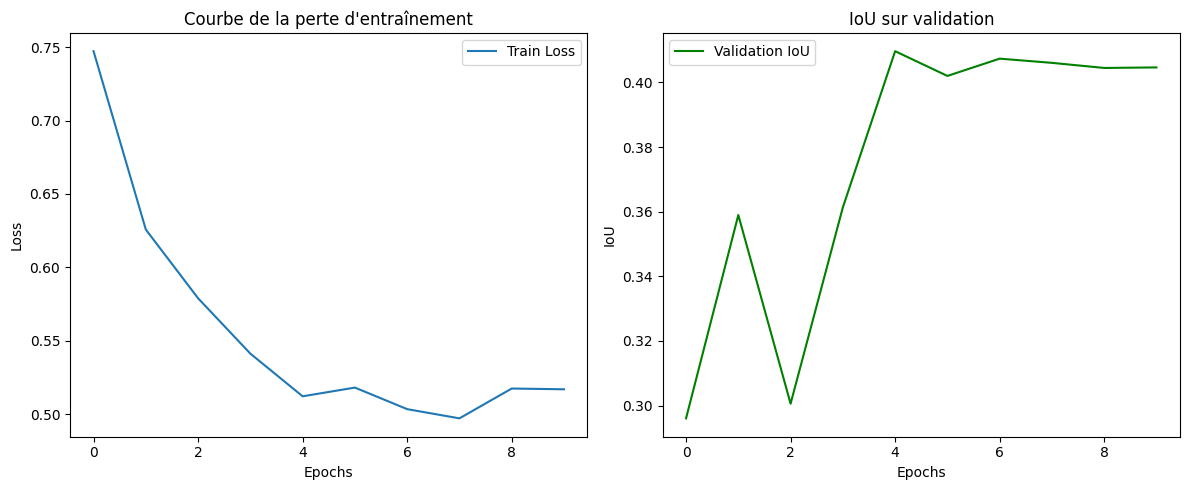

In [42]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Courbe de la perte d'entraînement")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_ious, label="Validation IoU", color='green')
plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.title("IoU sur validation")
plt.legend()

plt.tight_layout()
plt.show()


In [56]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T
import torchvision.ops

def visualize_predictions_with_masks(image, predictions, confidence_thresh=0.3, iou_thresh=0.2):
    """
    Visualise les prédictions avec masques et boxes
    Args:
        image (torch.Tensor): Image originale (C, H, W)
        predictions (dict): Sortie du modèle
        confidence_thresh (float): Seuil de confiance
        iou_thresh (float): Seuil pour NMS
    """
    # Conversion tenseur -> numpy
    img_np = image.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]))
    img_np = np.clip(img_np, 0, 1)
    
    # Extraction des prédictions
    boxes = predictions['boxes'].cpu()
    scores = predictions['scores'].cpu()
    labels = predictions['labels'].cpu()
    masks = predictions['masks'].cpu()
    
    # Filtrage par confiance
    keep = scores > confidence_thresh
    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]
    masks = masks[keep]
    
    # NMS
    keep_idx = torchvision.ops.nms(boxes, scores, iou_thresh)
    boxes = boxes[keep_idx]
    scores = scores[keep_idx]
    labels = labels[keep_idx]
    masks = masks[keep_idx]
    
    # Création du plot
    plt.figure(figsize=(12, 12))
    plt.imshow(img_np)
    
    for i in range(len(boxes)):
        # Masque
        mask = masks[i][0].numpy()
        mask = np.where(mask > 0.5, 1, 0)
        color = np.array([0.5, 0.2, 0.8])  # Violet visible
        
        # Application du masque
        masked_image = img_np.copy()
        masked_image[mask == 1] = masked_image[mask == 1] * 0.5 + color * 0.5
        
        # Boîte englobante
        x1, y1, x2, y2 = boxes[i].numpy()
        plt.gca().add_patch(plt.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            fill=False, edgecolor=color, linewidth=2
        ))
        
        # Étiquette
        label_text = f"{idx_to_class.get(labels[i].item(), 'Unknown')} ({scores[i]:.2f})"
        plt.text(x1, y1 - 10, label_text, 
                color='white', fontsize=12,
                bbox=dict(facecolor=color, alpha=0.9, boxstyle='round'))
    
    plt.axis('off')
    plt.show()

def predict_on_image(image_path, model, device, img_size=800):
    """
    Prédit sur une image quelconque
    Args:
        image_path (str): Chemin vers l'image
        model (nn.Module): Modèle entraîné
        device (torch.device): Device pour l'inférence
        img_size (int): Taille de redimensionnement
    """
    # Chargement et prétraitement
    img = Image.open(image_path).convert("RGB")
    original_size = img.size
    
    # Redimensionnement
    img = resize_with_aspect_ratio(img, img_size)
    img_tensor = transform(img).to(device)
    
    # Prédiction
    model.eval()
    with torch.no_grad():
        predictions = model([img_tensor])[0]
    
    # Conversion coordonnées vers original
    scale_x = original_size[0] / img_size
    scale_y = original_size[1] / img_size
    
    # Mise à l'échelle des boxes
    predictions['boxes'][:, [0, 2]] *= scale_x
    predictions['boxes'][:, [1, 3]] *= scale_y
    
    # Visualisation
    visualize_predictions_with_masks(img_tensor, predictions)

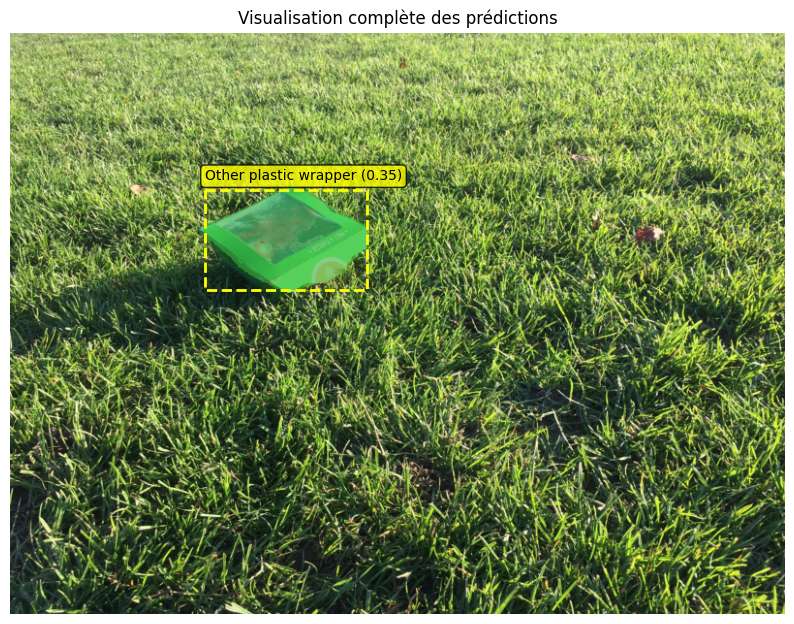

In [72]:
model.eval()

sample_img, sample_target = val_dataset[2]
with torch.no_grad():
    prediction = model([sample_img.to(DEVICE)])

# Dénormalisation
img_np = sample_img.permute(1, 2, 0).cpu().numpy()
img_np = (img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]))
img_np = np.clip(img_np, 0, 1)

plt.figure(figsize=(10, 10))

# Masques, boîtes, scores, labels
masks = prediction[0]['masks'].cpu().numpy()  # Conversion immédiate en numpy
boxes = prediction[0]['boxes'].cpu().numpy()
scores = prediction[0]['scores'].cpu().numpy()
labels = prediction[0]['labels'].cpu().numpy()

threshold = 0.3
mask_threshold = 0.3  # Seuil spécifique pour les masques

# Mapping ID -> nom de classe
id_to_class = {v: k for k, v in dataset.cat_map.items()}

# Création d'une copie pour les masques
masked_image = np.copy(img_np)

for i in range(len(masks)):
    if scores[i] < threshold:
        continue
    
    # Application du masque
    mask = masks[i, 0] > mask_threshold
    color = np.array([0.2, 0.7, 0.2])  # Vert fluo pour meilleure visibilité
    
    # Blend avec l'image originale
    masked_image[mask] = masked_image[mask] * 0.4 + color * 0.6

# Affichage de l'image avec masques
plt.imshow(masked_image)

# Ajout des boîtes et labels
for i in range(len(boxes)):
    if scores[i] < threshold:
        continue
    
    x1, y1, x2, y2 = boxes[i]
    plt.gca().add_patch(plt.Rectangle(
        (x1, y1), 
        x2 - x1, 
        y2 - y1,
        fill=False, 
        edgecolor='yellow', 
        linewidth=2,
        linestyle='--'
    ))
    
    class_id = labels[i]
    class_name = idx_to_class.get(class_id, f"Classe {class_id}")
    plt.text(
        x1, 
        y1 - 10, 
        f"{class_name} ({scores[i]:.2f})", 
        color='black',
        fontsize=10,
        bbox=dict(
            facecolor='yellow', 
            alpha=0.8, 
            edgecolor='black',
            boxstyle='round,pad=0.3'
        )
    )

plt.title("Visualisation complète des prédictions")
plt.axis('off')
plt.show()

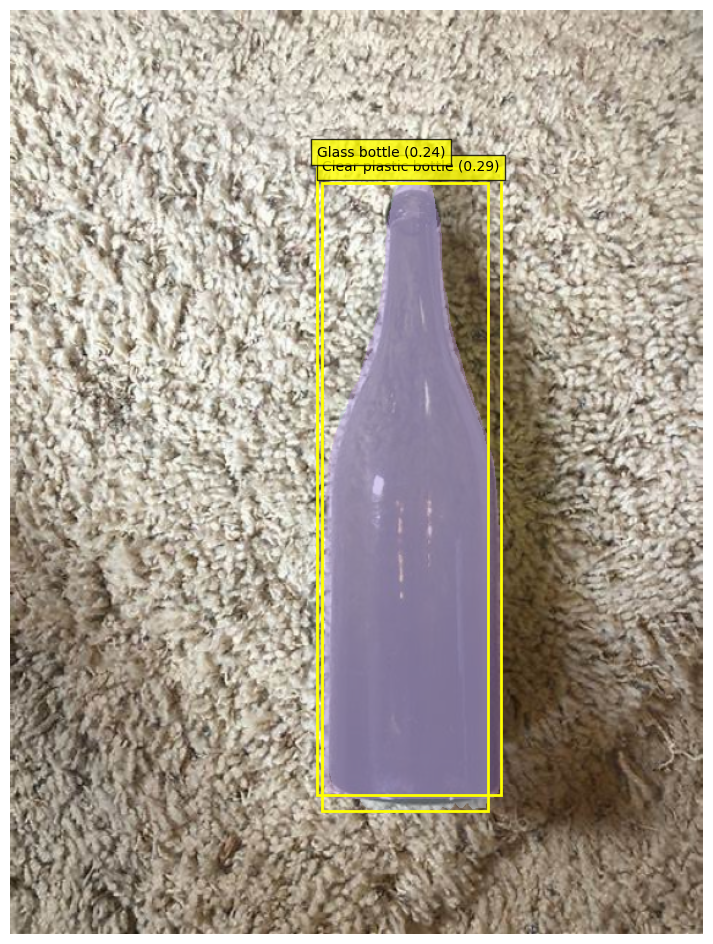

In [77]:
def visualize_predictions(image_tensor, predictions, confidence_thresh=0.2):
    """
    Visualise les prédictions avec masques, boîtes et labels
    Args:
        image_tensor (Tensor): Image normalisée (C, H, W)
        predictions (dict): Dictionnaire de prédictions
        confidence_thresh (float): Seuil de confiance
    """
    # Dénormalisation
    img_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]).clip(0, 1)
    
    # Filtrage des prédictions
    keep = predictions['scores'].cpu().numpy() > confidence_thresh
    boxes = predictions['boxes'].cpu().numpy()[keep]
    scores = predictions['scores'].cpu().numpy()[keep]
    labels = predictions['labels'].cpu().numpy()[keep]
    masks = predictions['masks'].cpu().numpy()[keep]

    # Création de l'image avec masques
    display_img = img_np.copy()
    for i, (mask, label) in enumerate(zip(masks, labels)):
        color = np.random.rand(3)
        display_img[mask[0] > 0.3] = display_img[mask[0] > 0.3] * 0.6 + color * 0.4

    plt.figure(figsize=(12, 12))
    plt.imshow(display_img)

    # Ajout des boîtes et labels
    for i, (box, score, label) in enumerate(zip(boxes, scores, labels)):
        x1, y1, x2, y2 = box
        plt.gca().add_patch(plt.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            fill=False, edgecolor='yellow', linewidth=2))
        
        class_name = idx_to_class.get(int(label), f'Classe {int(label)}')
        plt.text(x1, y1 - 10, f"{class_name} ({score:.2f})", 
                color='black', fontsize=10,
                bbox=dict(facecolor='yellow', alpha=0.8))

    plt.axis('off')
    plt.show()


# Pour les images externes
def predict_any_image(image_path):
    img = Image.open(image_path).convert("RGB")
    
    # Transformation identique à l'entraînement
    img_transformed = transform(resize_with_aspect_ratio(img, IMG_SIZE))
    
    # Prédiction
    with torch.no_grad():
        pred = model([img_transformed.to(DEVICE)])[0]
    
    # Visualisation
    visualize_predictions(img_transformed, pred)

# Exemple d'utilisation
predict_any_image("/kaggle/input/visuals/test6.jpg")

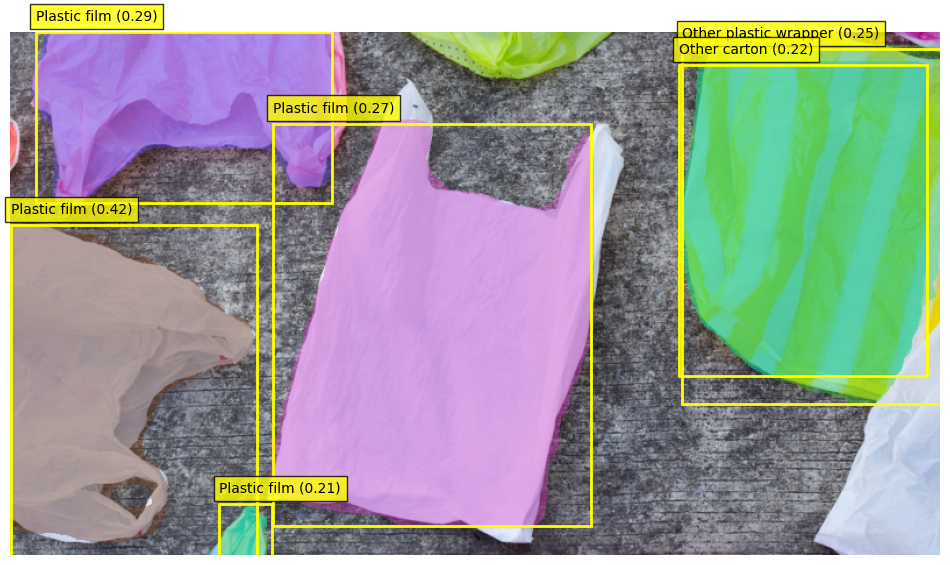

In [78]:
predict_any_image("/kaggle/input/visuals/test12.jpg")

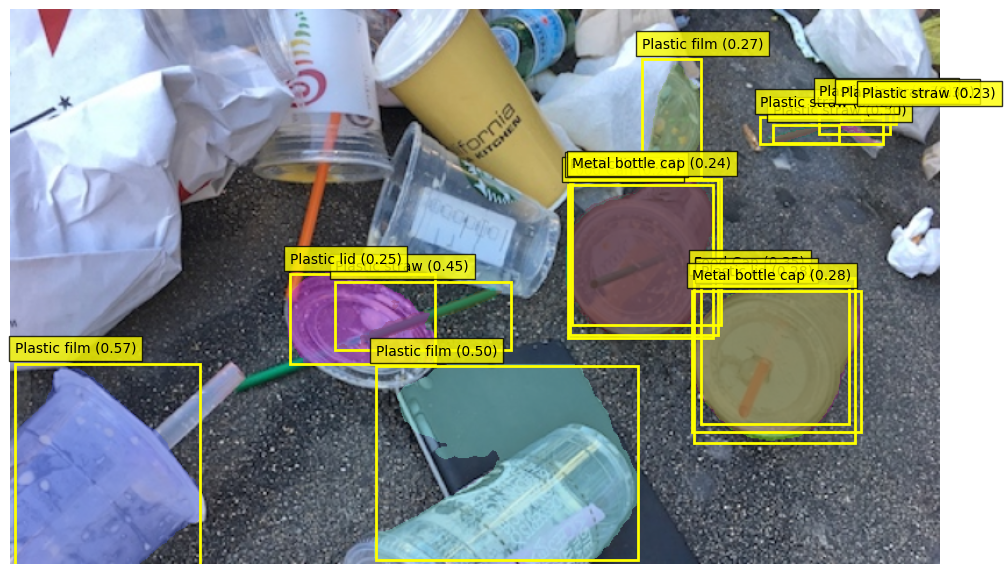

In [79]:
predict_any_image("/kaggle/input/visuals/test13.jpg")

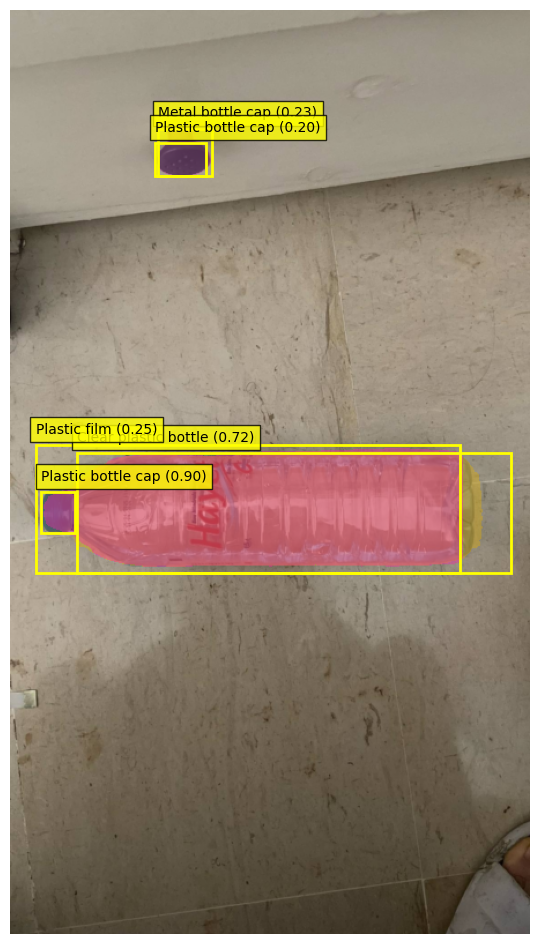

In [80]:
predict_any_image("/kaggle/input/visuals/test20.jpg")